In [33]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os

from sklearn.model_selection import train_test_split

data=pd.read_csv('Advertising.csv', header=0, nrows=160)
data.head()

,Number,TV,radio,newspaper,sales
0,1,230.1,37.8,69.2,22.1
1,2,44.5,39.3,45.1,10.4
2,3,17.2,45.9,69.3,9.3
3,4,151.5,41.3,58.5,18.5
4,5,180.8,10.8,58.4,12.9


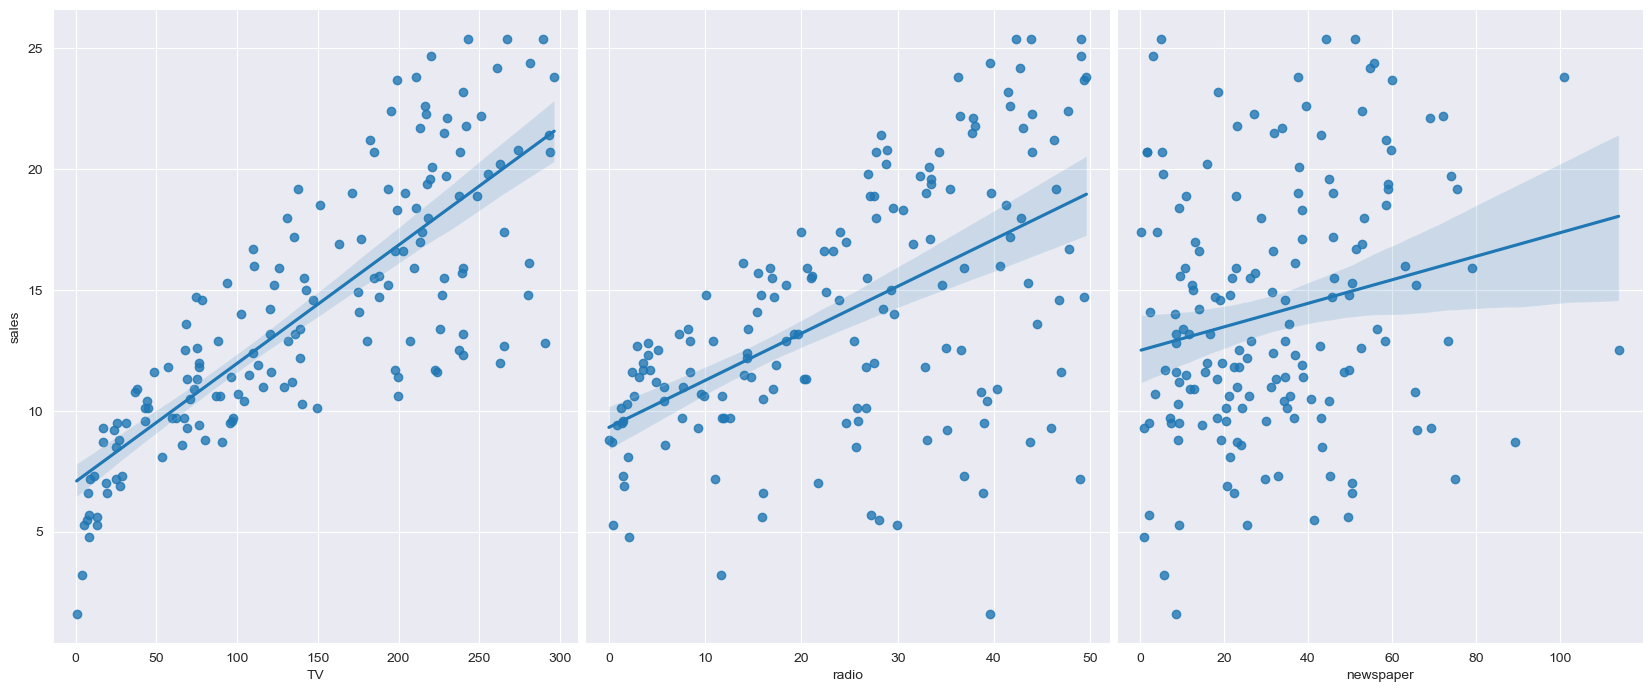

In [34]:
sns.pairplot(data
             , x_vars=['TV', 'radio', 'newspaper']
             , y_vars='sales'
             , height=7
             , aspect=0.8
             , kind='reg')
plt.show()

In [35]:
# 第一步: 构建特征矩阵和目标数组
Data=data.drop(['Number', "sales"], axis=1)
Data.head()

,TV,radio,newspaper
0,230.1,37.8,69.2
1,44.5,39.3,45.1
2,17.2,45.9,69.3
3,151.5,41.3,58.5
4,180.8,10.8,58.4


In [36]:
sales=data['sales']
type(sales)
sales

0      22.1
1      10.4
2       9.3
3      18.5
4      12.9
       ... 
155     3.2
156    15.3
157    10.1
158     7.3
159    12.9
Name: sales, Length: 160, dtype: float64

In [37]:
import numpy as np
sales = np.ravel(sales)
type(sales)

numpy.ndarray

In [38]:
sales

array([22.1, 10.4,  9.3, 18.5, 12.9,  7.2, 11.8, 13.2,  4.8, 10.6,  8.6,
       17.4,  9.2,  9.7, 19. , 22.4, 12.5, 24.4, 11.3, 14.6, 18. , 12.5,
        5.6, 15.5,  9.7, 12. , 15. , 15.9, 18.9, 10.5, 21.4, 11.9,  9.6,
       17.4,  9.5, 12.8, 25.4, 14.7, 10.1, 21.5, 16.6, 17.1, 20.7, 12.9,
        8.5, 14.9, 10.6, 23.2, 14.8,  9.7, 11.4, 10.7, 22.6, 21.2, 20.2,
       23.7,  5.5, 13.2, 23.8, 18.4,  8.1, 24.2, 15.7, 14. , 18. ,  9.3,
        9.5, 13.4, 18.9, 22.3, 18.3, 12.4,  8.8, 11. , 17. ,  8.7,  6.9,
       14.2,  5.3, 11. , 11.8, 12.3, 11.3, 13.6, 21.7, 15.2, 12. , 16. ,
       12.9, 16.7, 11.2,  7.3, 19.4, 22.2, 11.5, 16.9, 11.7, 15.5, 25.4,
       17.2, 11.7, 23.8, 14.8, 14.7, 20.7, 19.2,  7.2,  8.7,  5.3, 19.8,
       13.4, 21.8, 14.1, 15.9, 14.6, 12.6, 12.2,  9.4, 15.9,  6.6, 15.5,
        7. , 11.6, 15.2, 19.7, 10.6,  6.6,  8.8, 24.7,  9.7,  1.6, 12.7,
        5.7, 19.6, 10.8, 11.6,  9.5, 20.8,  9.6, 20.7, 10.9, 19.2, 20.1,
       10.4, 11.4, 10.3, 13.2, 25.4, 10.9, 10.1, 16

In [39]:
# 模型构建
import statsmodels.api as sm
X_add_const=sm.add_constant(Data.to_numpy())
myModel = sm.OLS(sales, X_add_const)
results=myModel.fit()
print(results.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.896
Model:                            OLS   Adj. R-squared:                  0.894
Method:                 Least Squares   F-statistic:                     448.7
Date:                Fri, 21 Mar 2025   Prob (F-statistic):           1.80e-76
Time:                        13:24:23   Log-Likelihood:                -310.02
No. Observations:                 160   AIC:                             628.0
Df Residuals:                     156   BIC:                             640.3
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          2.9490      0.358      8.236      0.0

In [41]:
# 第二步拆分训练集和测试集
import pandas as pd
data=pd.read_csv('Advertising.csv', header=0, nrows=160)
Data=data.drop(['Number', "sales"], axis=1)
sales=data['sales']
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(Data, sales, test_size=0.25, random_state=1)

In [43]:
# 查看训练数据与测试数据的数量
print(X_train.shape)
print(X_test.shape)

(120, 3)
(40, 3)


In [44]:
from sklearn.linear_model import LinearRegression
linreg=LinearRegression()
model=linreg.fit(X_train, y_train)
print(model)

LinearRegression()


In [46]:
model.coef_

array([0.04918032, 0.17349871, 0.00297027])

In [47]:
model.intercept_

np.float64(2.738847014889771)

In [48]:
# 准确率
model.score(X_train, y_train)

0.9036116940646572

In [49]:
# 模型预测
y_pred = linreg.predict(X_test)
y_pred

array([ 9.10814415, 21.98945041, 18.62129077,  4.50367124, 15.35323608,
       14.1864598 ,  8.5608026 , 17.47371234, 16.66074407, 15.54110747,
       16.58475654, 10.48217151, 10.18469287, 17.74639947, 18.24697637,
       10.22153153,  8.56262996, 20.70250784,  3.52854765, 14.5705147 ,
       15.6639519 , 17.77215881,  9.35283197, 11.87357288, 20.79968544,
       11.42483539, 12.76193642,  9.99522626,  8.97422871, 21.62564334,
        6.71043538, 15.01717525, 21.28759214, 16.41233648, 21.82357409,
       18.33507416, 21.79235276, 21.09852556, 19.27200593,  8.09614624])

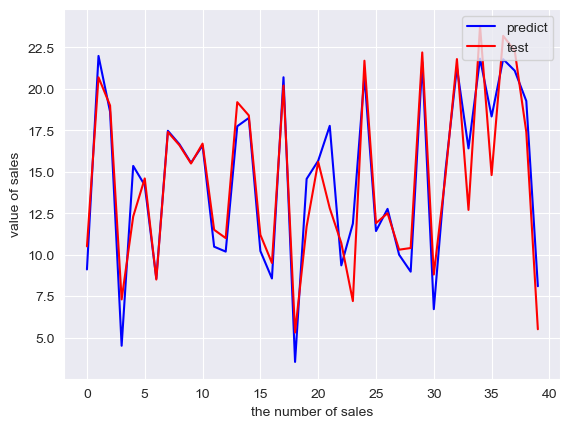

In [50]:
# 模型评价
import matplotlib.pyplot as plt
plt.figure()
plt.plot(range(len(y_pred)), y_pred, 'b', label="predict")
plt.plot(range(len(y_test)), y_test, 'r', label="test")
plt.legend(loc="upper right")
plt.xlabel("the number of sales")
plt.ylabel("value of sales")
plt.show()


In [51]:
data=pd.read_csv('Advertising.csv', header=0, nrows=160)
data.head()

,Number,TV,radio,newspaper,sales
0,1,230.1,37.8,69.2,22.1
1,2,44.5,39.3,45.1,10.4
2,3,17.2,45.9,69.3,9.3
3,4,151.5,41.3,58.5,18.5
4,5,180.8,10.8,58.4,12.9


In [52]:
X_data=data.drop(['Number', "sales"], axis=1)
X_data.head()

,TV,radio,newspaper
0,230.1,37.8,69.2
1,44.5,39.3,45.1
2,17.2,45.9,69.3
3,151.5,41.3,58.5
4,180.8,10.8,58.4


In [53]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
for i in range(3):
    print(X_data.columns[i], "->", variance_inflation_factor(X_data.to_numpy(),  i))

TV -> 2.4721397858626943
radio -> 3.6064012685130162
newspaper -> 3.2325002175143025
